 R Analytics Statistical Summary

In [ ]:
cat("==============================\n")
cat("STATISTICAL SUMMARY - NORTHSTAR\n")
cat("==============================\n\n")

cat("--- Customer Ratings ---\n")
print(summary(deliveries$customer_rating_post_delivery))

cat("\n--- Order Values ---\n")
print(summary(orders$order_value))

cat("\n--- Manual Route Overrides ---\n")
print(summary(deliveries$manual_route_override_count))

cat("\n--- Fuel / Charge Cost ---\n")
print(summary(deliveries$fuel_or_charge_cost))

cat("\n--- Driver Training Scores ---\n")
print(summary(drivers$training_score))

STATISTICAL SUMMARY - NORTHSTAR

--- Customer Ratings ---
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
  1.000   3.360   4.040   3.865   4.550   5.000      14 

--- Order Values ---
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   2.04   47.91   76.53   91.05  121.10  510.06 

--- Manual Route Overrides ---
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.0000  1.0000  0.9695  2.0000  7.0000 

--- Fuel / Charge Cost ---
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  2.500   9.925  12.645  12.841  15.697  29.430 

--- Driver Training Scores ---
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
  40.60   68.55   75.20   74.91   82.75   99.00       7 


 Chart 1 (Delivery Status by Hub)

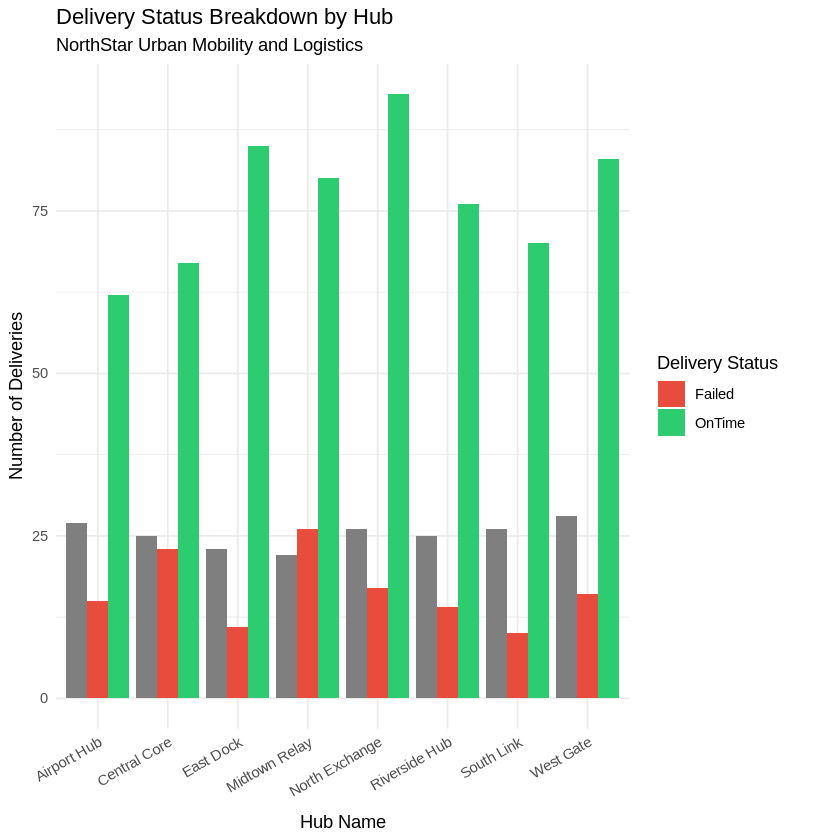

In [ ]:
hub_delivery <- merge(deliveries, hubs, by="hub_id")

ggplot(hub_delivery, aes(x=hub_name, fill=delivery_status)) +
  geom_bar(position="dodge") +
  scale_fill_manual(values=c("Failed"="#e74c3c",
                              "OnTime"="#2ecc71",
                              "Late"="#f39c12")) +
  labs(title="Delivery Status Breakdown by Hub",
       subtitle="NorthStar Urban Mobility and Logistics",
       x="Hub Name", y="Number of Deliveries",
       fill="Delivery Status") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle=30, hjust=1))

Chart 2 (Customer Rating Distribution)

Warning message:
“Removed 14 rows containing non-finite outside the scale range (`stat_bin()`).”


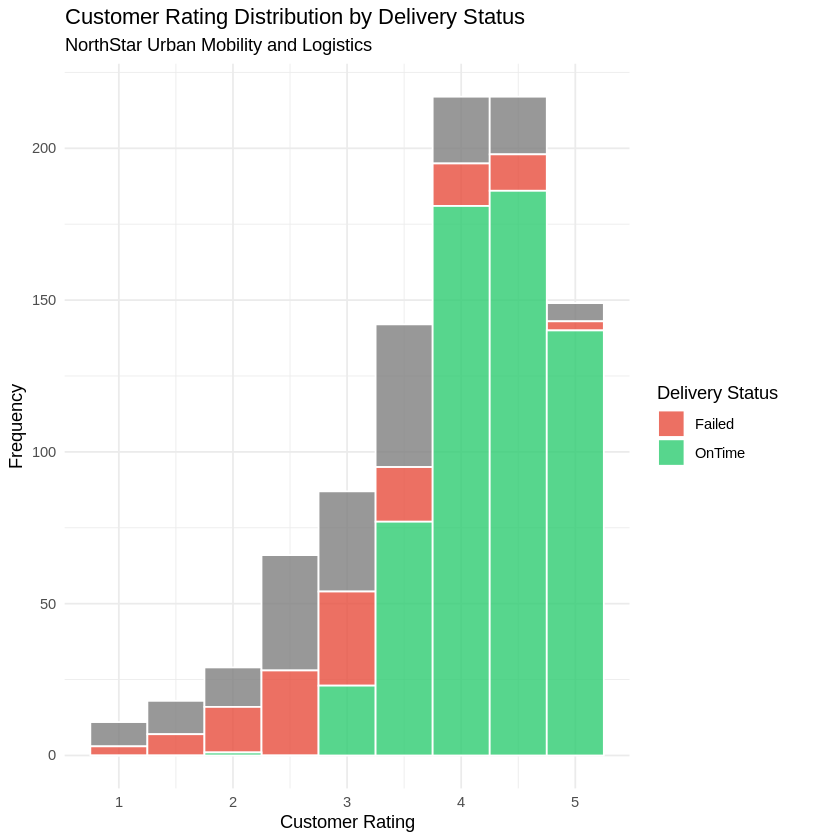

In [ ]:
ggplot(deliveries, aes(x=customer_rating_post_delivery,
                        fill=delivery_status)) +
  geom_histogram(binwidth=0.5, color="white", alpha=0.8) +
  scale_fill_manual(values=c("Failed"="#e74c3c",
                              "OnTime"="#2ecc71",
                              "Late"="#f39c12")) +
  labs(title="Customer Rating Distribution by Delivery Status",
       subtitle="NorthStar Urban Mobility and Logistics",
       x="Customer Rating", y="Frequency",
       fill="Delivery Status") +
  theme_minimal()

 Chart 3 (Order Value by Service Type)

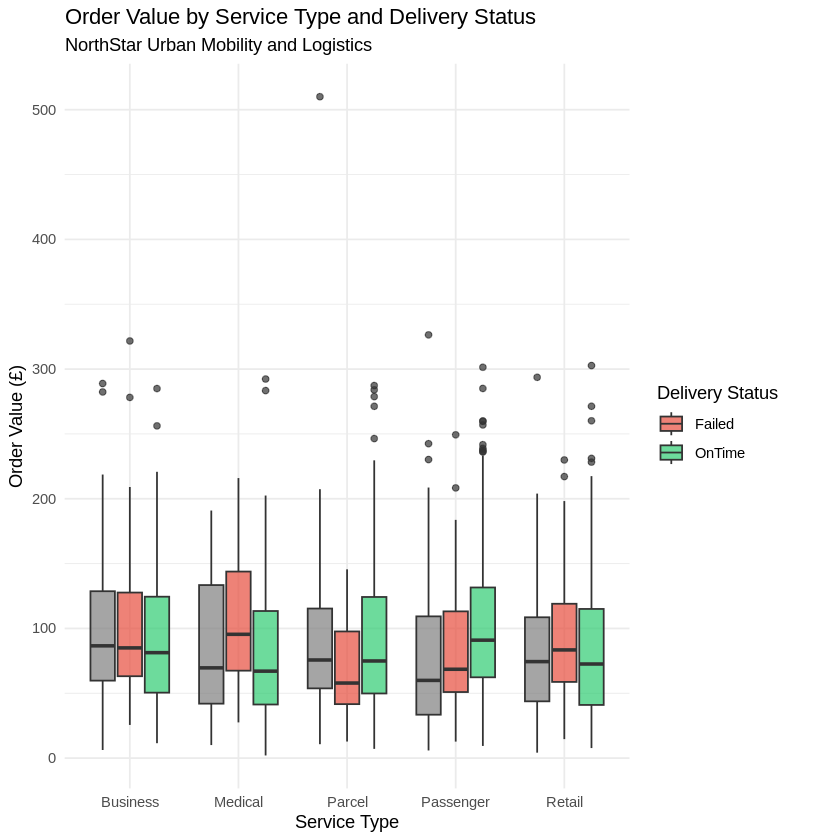

In [ ]:
merged_data <- merge(orders, deliveries, by="order_id")

ggplot(merged_data, aes(x=service_type,
                         y=order_value,
                         fill=delivery_status)) +
  geom_boxplot(alpha=0.7) +
  scale_fill_manual(values=c("Failed"="#e74c3c",
                              "OnTime"="#2ecc71",
                              "Late"="#f39c12")) +
  labs(title="Order Value by Service Type and Delivery Status",
       subtitle="NorthStar Urban Mobility and Logistics",
       x="Service Type", y="Order Value (£)",
       fill="Delivery Status") +
  theme_minimal()

Chart 4 (Overrides vs Rating Correlation)

Pearson Correlation Coefficient: -0.0599 
Interpretation: Weak negative correlation


`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 14 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 14 rows containing missing values or values outside the scale range
(`geom_point()`).”


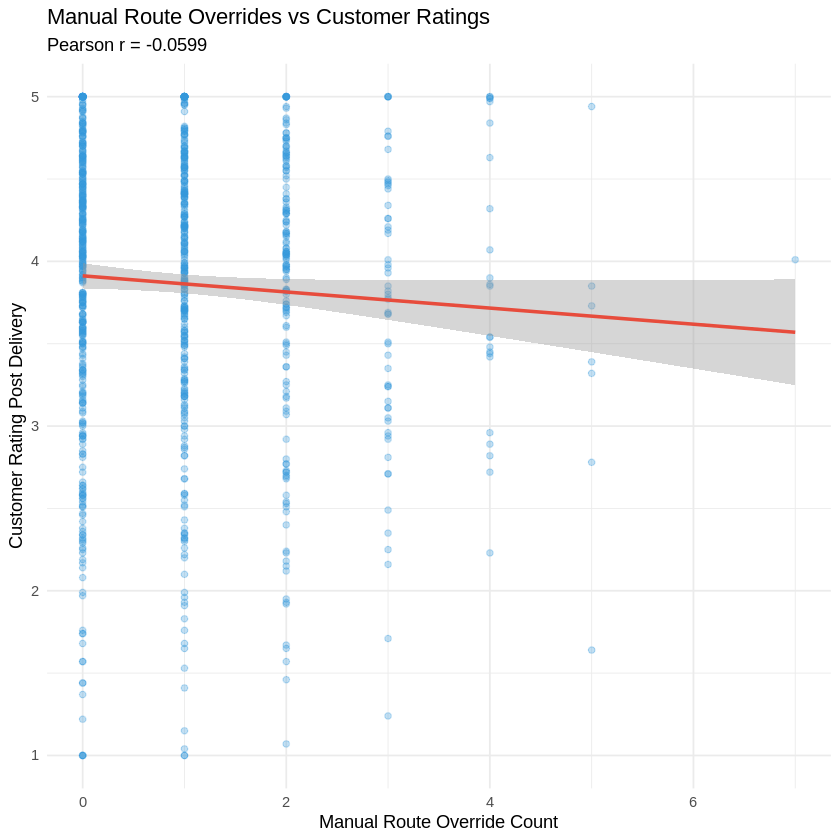

In [ ]:
corr_value <- cor(deliveries$manual_route_override_count,
                  deliveries$customer_rating_post_delivery,
                  use="complete.obs")
cat("Pearson Correlation Coefficient:", round(corr_value, 4), "\n")

if(corr_value < -0.3) {
  cat("Interpretation: Moderate to strong NEGATIVE correlation\n")
  cat("More overrides = lower customer satisfaction\n")
} else if(corr_value < 0) {
  cat("Interpretation: Weak negative correlation\n")
} else {
  cat("Interpretation: Positive or no correlation\n")
}

ggplot(deliveries, aes(x=manual_route_override_count,
                        y=customer_rating_post_delivery)) +
  geom_point(alpha=0.3, color="#3498db", size=1.5) +
  geom_smooth(method="lm", color="#e74c3c", se=TRUE) +
  labs(title="Manual Route Overrides vs Customer Ratings",
       subtitle=paste("Pearson r =", round(corr_value, 4)),
       x="Manual Route Override Count",
       y="Customer Rating Post Delivery") +
  theme_minimal()

Chart - 5(Delivery Failure Rate by Zone)

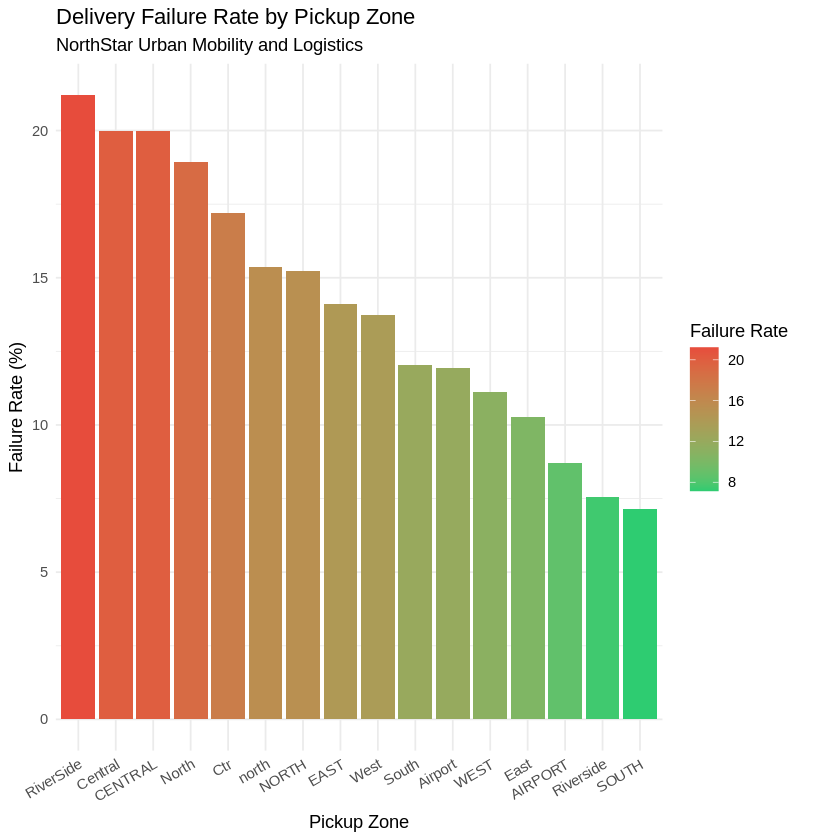

In [ ]:
# Chart 5: Delivery Failure Rate by Zone
zone_summary <- sqldf("
  SELECT o.pickup_zone,
         COUNT(*) AS total,
         SUM(CASE WHEN d.delivery_status = 'Failed'
             THEN 1 ELSE 0 END) AS failed,
         ROUND(SUM(CASE WHEN d.delivery_status = 'Failed'
             THEN 1 ELSE 0 END) * 100.0 /
             COUNT(*), 2) AS failure_rate_pct
  FROM orders o
  JOIN deliveries d ON o.order_id = d.order_id
  GROUP BY o.pickup_zone
  ORDER BY failure_rate_pct DESC
")

ggplot(zone_summary,
       aes(x=reorder(pickup_zone, -failure_rate_pct),
           y=failure_rate_pct,
           fill=failure_rate_pct)) +
  geom_bar(stat="identity") +
  scale_fill_gradient(low="#2ecc71", high="#e74c3c") +
  labs(
    title="Delivery Failure Rate by Pickup Zone",
    subtitle="NorthStar Urban Mobility and Logistics",
    x="Pickup Zone",
    y="Failure Rate (%)",
    fill="Failure Rate") +
  theme_minimal() +
  theme(axis.text.x=element_text(angle=30, hjust=1))